# Statistical Dependency Analysis

This notebook implements:
- Statistical dependency analysis (Chi-square test)
- Feature relationship assessment
- Linear Regression baseline model
- Random Forest, XGBoost, LightGBM and MLP models
- Hyperparameter optimization
- Feature importance and SHAP interpretation
- Model evaluation on training and control datasets


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from itertools import combinations
from scipy.stats import chi2_contingency
from sklearn.metrics import r2_score
from scipy.stats import randint, uniform

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

## Data Loading

The dataset consists of two parts:
- Training dataset — used for analysis and model building
- Control dataset — used for final model evaluation


In [3]:
file_path = "Task_1.xlsx"

df_test = pd.read_excel(file_path, header=0, sheet_name='Control dataset', engine='openpyxl')
df_train = pd.read_excel(file_path, header=0, sheet_name='Training dataset', engine='openpyxl')

## Initial Data Inspection

I perform a basic inspection to understand feature structure and data quality.


In [4]:
df_train

,Unnamed: 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,Feature 10,NPV
0,1,P10,P10P50,X,P90,X,P50P90,P90P50,P90P50,P10P50,P50P10,1871.515361
1,2,P10,P50P50,P50,P90,P50P10,P10P10,P90P50,P10P90,P10P50,P90P50,5345.484763
2,3,P50,P10P90,P10,P50,P90P50,P10P50,P50P90,P10P50,P10P90,P50P90,2754.839189
3,4,P90,P90P50,P10,P10,P90P50,P10P10,P10P90,P10P10,P90P10,P90P50,2111.623643
4,5,P50,P50P10,P90,P10,P90P50,P90P10,P10P50,P10P90,P10P10,P10P10,3824.497677
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,P50,P10P50,P90,P10,P50P50,P10P10,P10P90,P10P10,P10P10,P10P90,6735.878855
2996,2997,X,P50P50,X,P50,P10P50,P50P90,P50P10,P50P90,P90P10,X,996.932002
2997,2998,X,P50P10,X,P10,P50P50,P10P90,P10P50,P10P90,P90P50,P90P50,391.183048
2998,2999,P90,P50P10,P10,P10,P90P50,X,P10P90,P50P90,P90P50,P90P10,-530.189254


In [5]:
df_test

,Unnamed: 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,Feature 10,NPV
0,1,P10,P50P10,P90,P50,P10P50,P50P90,P50P10,P90P10,P90P50,X,-856.516819
1,2,P50,P50P90,P90,P50,P50P50,P50P50,P50P50,P50P50,P10P50,X,3104.008252
2,3,P50,P10P90,P10,P50,P10P50,P50P10,P50P10,P10P50,P90P10,P90P50,1861.284693
3,4,P90,P10P90,P10,P10,P10P10,X,P10P90,P90P50,P50P10,P50P10,3319.254616
4,5,P50,P10P50,P50,P50,X,P10P90,P50P50,P10P50,P90P50,P50P90,209.204910
...,...,...,...,...,...,...,...,...,...,...,...,...
745,746,P50,P90P50,P10,P10,P90P50,P50P10,P10P90,P90P10,P10P10,P50P10,4924.583685
746,747,P10,P50P50,P10,P90,X,P90P10,P90P50,P50P10,P90P50,P50P90,-1468.493009
747,748,X,P50P10,P90,P10,P50P10,P90P10,P10P50,P50P50,P50P50,P50P90,2305.464411
748,749,P50,P10P10,P10,P10,P50P50,P90P50,P10P10,X,P50P10,P90P10,1490.848158


In [6]:
df_train.describe()

,Unnamed: 0,NPV
count,3000.000000,3000.000000
mean,1500.500000,2058.131403
std,866.169729,2096.831164
min,1.000000,-3848.172884
25%,750.750000,598.758314
50%,1500.500000,1988.356405
75%,2250.250000,3501.320204
max,3000.000000,9220.000000


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  3000 non-null   int64  
 1   Feature 1   3000 non-null   object 
 2   Feature 2   3000 non-null   object 
 3   Feature 3   3000 non-null   object 
 4   Feature 4   3000 non-null   object 
 5   Feature 5   3000 non-null   object 
 6   Feature 6   3000 non-null   object 
 7   Feature 7   3000 non-null   object 
 8   Feature 8   3000 non-null   object 
 9   Feature 9   3000 non-null   object 
 10  Feature 10  3000 non-null   object 
 11  NPV         3000 non-null   float64
dtypes: float64(1), int64(1), object(10)
memory usage: 281.4+ KB


## Data Preprocessing and Encoding

Categorical project features are encoded numerically to enable statistical analysis
and regression modeling.

Missing or placeholder values are handled explicitly.


In [8]:
df_test.replace('X', 0, inplace=True)
df_train.replace('X', 0, inplace=True)


data_encoding = {'P90P90': 1, 'P90P50': 2, 'P50P90': 3,
        'P90P10': 4, 'P50P50': 5, 'P10P90': 6, 'P90': 7,
        'P50P10': 8, 'P10P50': 9, 'P50': 10, 'P10P10': 11, 'P10': 12}

df_test.replace(data_encoding, inplace=True)
df_train.replace(data_encoding, inplace=True)
df_train

C:\Users\pc\AppData\Local\Temp\ipykernel_4556\873565939.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test.replace(data_encoding, inplace=True)
C:\Users\pc\AppData\Local\Temp\ipykernel_4556\873565939.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train.replace(data_encoding, inplace=True)


,Unnamed: 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,Feature 10,NPV
0,1,12,9,0,7,0,3,2,2,9,8,1871.515361
1,2,12,5,10,7,8,11,2,6,9,2,5345.484763
2,3,10,6,12,10,2,9,3,9,6,3,2754.839189
3,4,7,2,12,12,2,11,6,11,4,2,2111.623643
4,5,10,8,7,12,2,4,9,6,11,11,3824.497677
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,10,9,7,12,5,11,6,11,11,6,6735.878855
2996,2997,0,5,0,10,9,3,8,3,4,0,996.932002
2997,2998,0,8,0,12,5,6,9,6,2,2,391.183048
2998,2999,7,8,12,12,2,0,6,3,2,4,-530.189254


## Statistical Dependency Analysis

I test statistical hypotheses of independence between each pair of categorical features
using the Chi-square test.

Significance level: α = 0.05


In [ ]:
selected_columns = df_train.columns[1:11]
alpha = 0.05
chi2_results = []

for col1, col2 in combinations(selected_columns, 2):
    conjugacy_table = pd.crosstab(df_train[col1], df_train[col2]) 
    chi2, p, dof, expected = chi2_contingency(conjugacy_table)

    chi2_results.append({
        'Feature 1': col1,
        'Feature 2': col2,
        'chi2': chi2,
        'p_value': p,
        'Dependency': 'Yes' if p < alpha else 'No'
    })

chi2_df = pd.DataFrame(chi2_results)
chi2_df

,Feature 1,Feature 2,chi2,p_value,Dependency
0,Feature 1,Feature 2,21.818674,5.900886e-01,No
1,Feature 1,Feature 3,10.618668,3.027551e-01,No
2,Feature 1,Feature 4,4.688528,5.843360e-01,No
3,Feature 1,Feature 5,18.523451,7.769033e-01,No
4,Feature 1,Feature 6,28.469277,2.407452e-01,No
5,Feature 1,Feature 7,26.411361,1.911961e-01,No
6,Feature 1,Feature 8,30.500996,1.686974e-01,No
7,Feature 1,Feature 9,9.921370,9.799148e-01,No
8,Feature 1,Feature 10,15.580780,9.026102e-01,No
9,Feature 2,Feature 3,22.229066,5.655968e-01,No


## Proxy NPV Model

A Linear Regression model is implemented manually using the normal equation
to ensure full transparency and interpretability of the estimation process.


In [12]:
class my_LinearRegression:
    
    def fit(self, X, y):
        X = np.array(X)
        X = np.c_[np.ones(X.shape[0]), X]
        y = np.array(y)
        self.coef = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    def predict(self, X):
        X = np.array(X)
        X = np.c_[np.ones(X.shape[0]), X]
        return X.dot(self.coef)

## Model Training and Evaluation


In [13]:
X_train = df_train[selected_columns]
y_train = df_train['NPV']

X_test = df_test[selected_columns]
y_test = df_test['NPV']

model = my_LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f'test R² = {r2_test}')
print(f'train R² = {r2_train}')

test R² = 0.847338209046218
train R² = 0.8420855473646629


## Visualization of Results


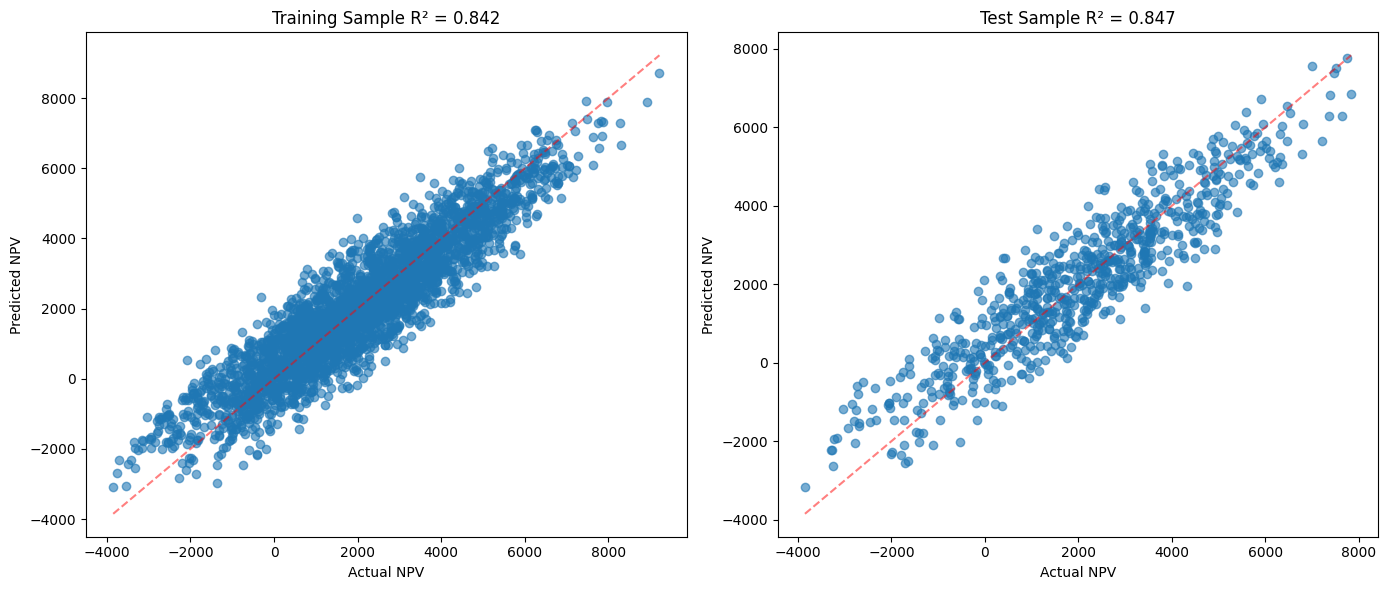

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(y_train, y_pred_train, alpha=0.6)
ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', alpha=0.5)
ax1.set_xlabel("Actual NPV")
ax1.set_ylabel("Predicted NPV")
ax1.set_title(f"Training Sample R² = {r2_train:.3f}")

ax2.scatter(y_test, y_pred_test, alpha=0.6)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', alpha=0.5)
ax2.set_xlabel("Actual NPV")
ax2.set_ylabel("Predicted NPV")
ax2.set_title(f"Test Sample R² = {r2_test:.3f}")

plt.tight_layout()
plt.show()

## Linear Correlation Matrix


In [13]:
signs = df_train[selected_columns]
matrix_correlation = signs.corr()

highlight = matrix_correlation.copy()
highlight[np.abs(highlight) < 0.2] = np.nan
annot_highlight = highlight.map(lambda x: f"{x:.2f}" if pd.notnull(x) else "")

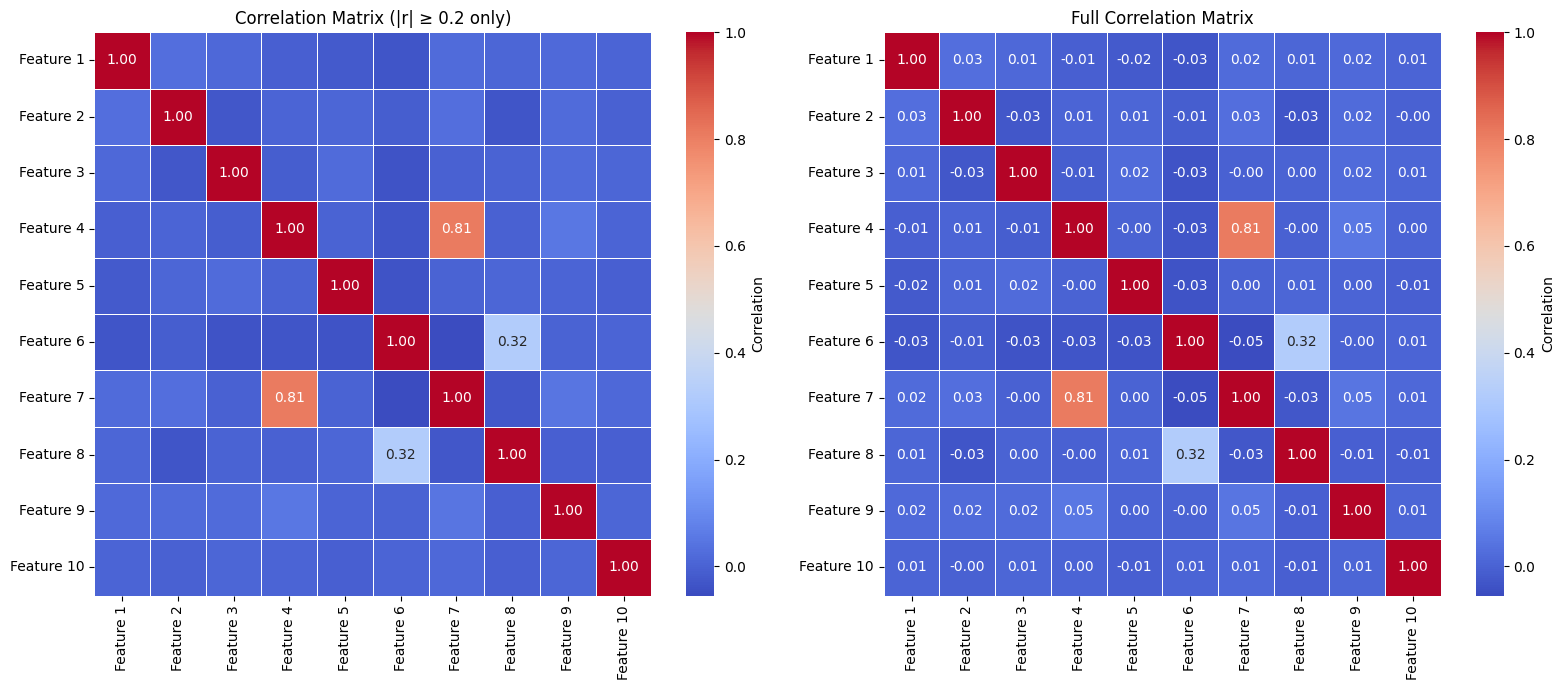

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(matrix_correlation, 
            annot=annot_highlight, 
            cmap='coolwarm', 
            fmt="", 
            linewidths=0.5,
            ax=ax1,
            cbar_kws={'label': 'Correlation'})
ax1.set_title("Correlation Matrix (|r| ≥ 0.2 only)", fontsize=12)

sns.heatmap(matrix_correlation, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            linewidths=0.5,
            ax=ax2,
            cbar_kws={'label': 'Correlation'})
ax2.set_title("Full Correlation Matrix", fontsize=12)

plt.tight_layout()
plt.show()

# RANDOM FOREST

In [16]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_train_pr = rf_model.predict(X_train)
rf_test_pr = rf_model.predict(X_test)

rf_r2_train = r2_score(y_train, rf_train_pr)
rf_r2_test = r2_score(y_test, rf_test_pr)

print("Random Forest:")
print(f"Train R²: {rf_r2_train:.3f}")
print(f"Test R²: {rf_r2_test:.3f}")

Random Forest:
Train R²: 0.979
Test R²: 0.935


### Hyperparametr tuning - GridSearch 

In [ ]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 4, 5, 6, 10],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)

print(grid_rf.best_params_)
print(grid_rf.best_score_)

Fitting 5 folds for each of 160 candidates, totalling 800 fits
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 400}
0.9224575973139295


## Visualization of Random Forest results

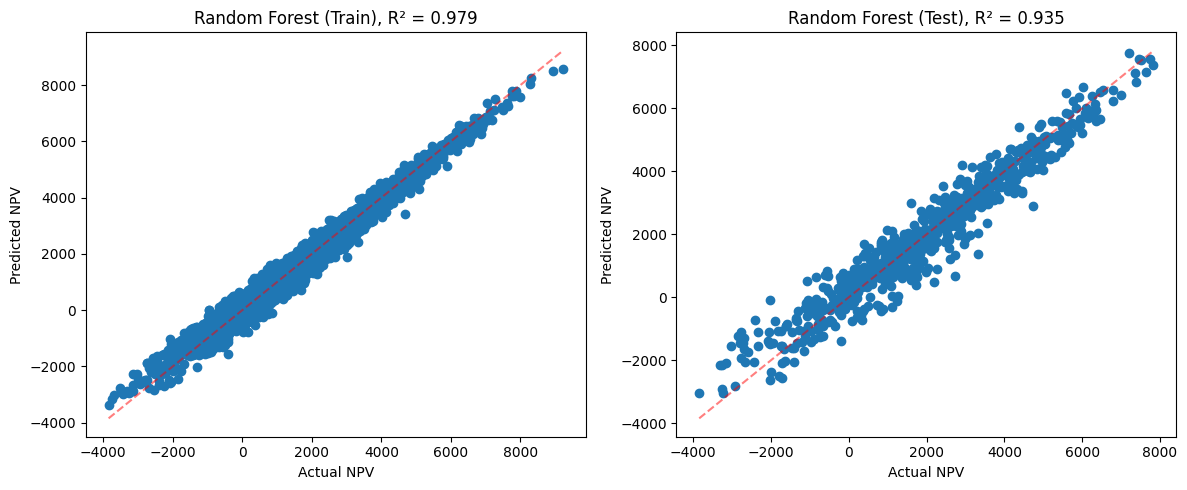

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(y_train, rf_train_pr)
ax1.set_xlabel("Actual NPV")
ax1.set_ylabel("Predicted NPV")
ax1.set_title(f"Random Forest (Train), R² = {rf_r2_train:.3f}")
ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', alpha=0.5)

ax2.scatter(y_test, rf_test_pr)
ax2.set_xlabel("Actual NPV")
ax2.set_ylabel("Predicted NPV")
ax2.set_title(f"Random Forest (Test), R² = {rf_r2_test:.3f}")
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', alpha=0.5)

plt.tight_layout()
plt.show()

#### Feature importance

In [19]:
feature_importance = pd.DataFrame({
    'feature': selected_columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feature_importance)

      feature  importance
8   Feature 9    0.494778
5   Feature 6    0.235551
4   Feature 5    0.178670
3   Feature 4    0.037838
9  Feature 10    0.021990
6   Feature 7    0.008957
1   Feature 2    0.008140
7   Feature 8    0.006186
0   Feature 1    0.004217
2   Feature 3    0.003672


# GRADIENT BOOSTING

## XGBRegressor

In [21]:
xgb_model = XGBRegressor(
    n_estimators=618,
    learning_rate=0.031448,
    max_depth=3,
    subsample=0.7586,
    colsample_bytree=0.74,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_train_pr = xgb_model.predict(X_train)
xgb_test_pr = xgb_model.predict(X_test)

xgb_r2_train = r2_score(y_train, xgb_train_pr)
xgb_r2_test = r2_score(y_test, xgb_test_pr)

print("XGBoost:")
print(f"Train R²: {xgb_r2_train:.3f}")
print(f"Test R²: {xgb_r2_test:.3f}")

XGBoost:
Train R²: 0.974
Test R²: 0.966


### Hyperparametr tuning - RandomizedSearch

In [ ]:
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

param_dist = {
    'n_estimators': randint(100, 700),

    'max_depth': randint(3, 12),

    'learning_rate': uniform(0.01, 0.15),

    'subsample': uniform(0.6, 0.4),

    'colsample_bytree': uniform(0.6, 0.4),

    'min_child_weight': randint(1, 10),

    'gamma': uniform(0, 0.5),

    'reg_alpha': uniform(0, 1),

    'reg_lambda': uniform(0.5, 5)
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,

    n_iter=50,

    scoring='r2',

    cv=5,

    verbose=2,

    random_state=42,

    n_jobs=-1,

    return_train_score=True
)

random_search_xgb.fit(X_train, y_train)

print("Best parameters:")
print(random_search_xgb.best_params_)

print("\nBest CV score:")
print(random_search_xgb.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters:
{'colsample_bytree': np.float64(0.7403660050208315), 'gamma': np.float64(0.05853350821380293), 'learning_rate': np.float64(0.031448752307925376), 'max_depth': 3, 'min_child_weight': 6, 'n_estimators': 618, 'reg_alpha': np.float64(0.4260914750469411), 'reg_lambda': np.float64(1.6128820878551526), 'subsample': np.float64(0.7586606407817007)}

Best CV score:
0.9662414091851828


In [23]:
best_xgb = random_search_xgb.best_estimator_

xgb_train_pred = best_xgb.predict(X_train)
xgb_test_pred = best_xgb.predict(X_test)

xgb_train_r2 = r2_score(y_train, xgb_train_pred)
xgb_test_r2 = r2_score(y_test, xgb_test_pred)

print(f"Train R²: {xgb_train_r2:.3f}")
print(f"Test R²: {xgb_test_r2:.3f}")

Train R²: 0.974
Test R²: 0.966


## LGBMRegressor

In [ ]:
lgb_model = LGBMRegressor(
    n_estimators=476,
    learning_rate=0.06344,
    max_depth=3,
    random_state=42
)

lgb_model.fit(X_train, y_train)

lgb_test_pr = lgb_model.predict(X_test)
lgb_train_pr = lgb_model.predict(X_train)

lgb_r2_test = r2_score(y_test, lgb_test_pr)
lgb_r2_train = r2_score(y_train, lgb_train_pr)

print("\nLightGBM:")
print(f"Train R²: {lgb_r2_train:.3f}")
print(f"Test R²: {lgb_r2_test:.3f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000191 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 75
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 10
[LightGBM] [Info] Start training from score 2058.131402
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

### Hyperparametr tuning - RandomizedSearch

In [ ]:
lgb = LGBMRegressor(
    random_state=42,
    verbose=-1
)

param_dist_lgb = {

    'n_estimators': randint(100, 700),

    'learning_rate': uniform(0.01, 0.15),

    'num_leaves': randint(15, 120),

    'max_depth': randint(3, 15),

    'min_child_samples': randint(5, 50),

    'subsample': uniform(0.6, 0.4),

    'colsample_bytree': uniform(0.6, 0.4),

    'reg_alpha': uniform(0, 1),

    'reg_lambda': uniform(0.5, 5)
}

random_search_lgb = RandomizedSearchCV(

    estimator=lgb,

    param_distributions=param_dist_lgb,

    n_iter=50,

    scoring='r2',

    cv=5,

    verbose=2,

    random_state=42,

    n_jobs=-1,

    return_train_score=True
)

random_search_lgb.fit(X_train, y_train)

print("Best params:")
print(random_search_lgb.best_params_)

print("\nBest CV score:")
print(random_search_lgb.best_score_)

KeyboardInterrupt: 

In [26]:
best_lgb = random_search_lgb.best_estimator_

lgb_train_pred = best_lgb.predict(X_train)
lgb_test_pred = best_lgb.predict(X_test)

print("Train R²:",
      r2_score(y_train, lgb_train_pred))

print("Test R²:",
      r2_score(y_test, lgb_test_pred))

Train R²: 0.9749869963953705
Test R²: 0.966038892503379


## Visualization of Gradient Boosting results

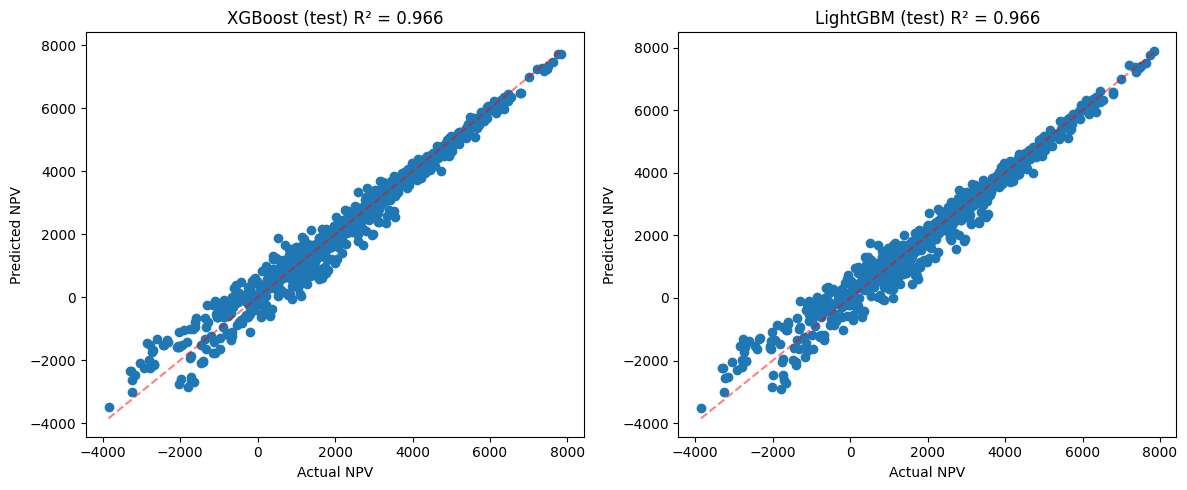

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(y_test, xgb_test_pr)
ax1.set_xlabel("Actual NPV")
ax1.set_ylabel("Predicted NPV")
ax1.set_title(f"XGBoost (test) R² = {xgb_r2_test:.3f}")
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', alpha=0.5) 

ax2.scatter(y_test, lgb_test_pr)
ax2.set_xlabel("Actual NPV")
ax2.set_ylabel("Predicted NPV")
ax2.set_title(f"LightGBM (test) R² = {lgb_r2_test:.3f}")
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', alpha=0.5)

plt.tight_layout()
plt.show()

#### Feature importance

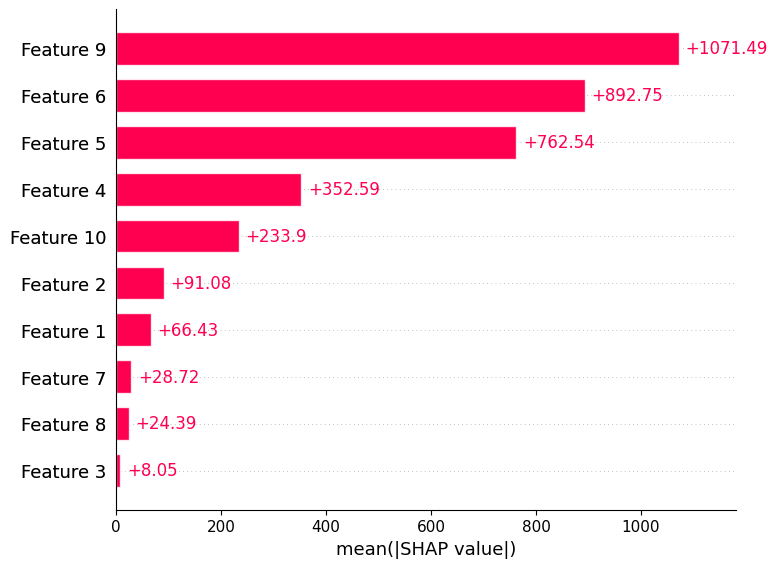

In [29]:
explainer = shap.Explainer(xgb_model)

shap_values = explainer(X_test)
shap.plots.bar(shap_values)

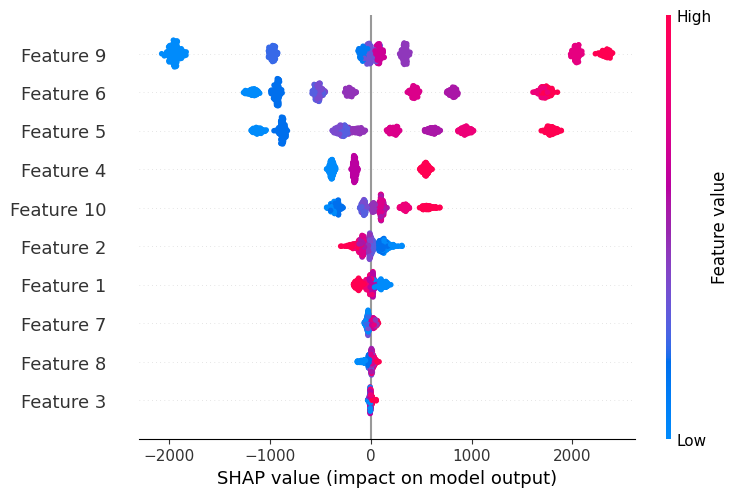

In [30]:
shap.plots.beeswarm(shap_values)

# MLP

In [14]:
scaler = StandardScaler()

X_train_mlp = scaler.fit_transform(X_train)
X_test_mlp = scaler.transform(X_test)

mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    alpha=0.0005,
    learning_rate_init=0.001,
    max_iter=1500,
    random_state=42
)

mlp.fit(X_train_mlp, y_train)

mlp_train_pred = mlp.predict(X_train_mlp)
mlp_test_pred = mlp.predict(X_test_mlp)

mlp_r2_train = r2_score(y_train, mlp_train_pred)
mlp_r2_test = r2_score(y_test, mlp_test_pred)

print("MLP:")
print(f"Train R²: {mlp_r2_train:.3f}")
print(f"Test R²: {mlp_r2_test:.3f}")

MLP:
Train R²: 0.966
Test R²: 0.861


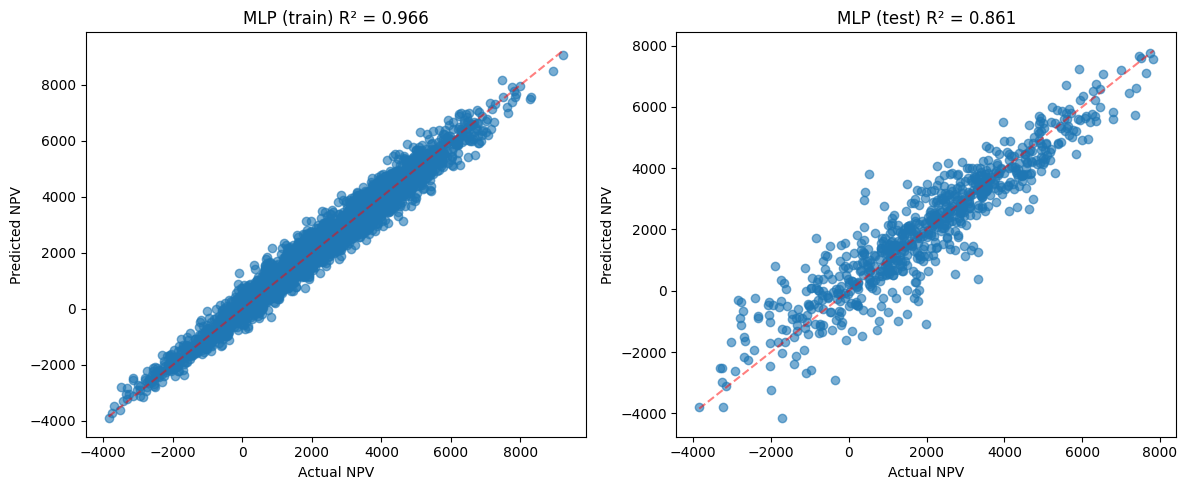

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(y_train, mlp_train_pred, alpha=0.6)
ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', alpha=0.5)
ax1.set_xlabel("Actual NPV")
ax1.set_ylabel("Predicted NPV")
ax1.set_title(f"MLP (train) R² = {mlp_r2_train:.3f}")

ax2.scatter(y_test, mlp_test_pred, alpha=0.6)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', alpha=0.5)
ax2.set_xlabel("Actual NPV")
ax2.set_ylabel("Predicted NPV")
ax2.set_title(f"MLP (test) R² = {mlp_r2_test:.3f}")

plt.tight_layout()
plt.show()

## Conclusions

- Statistically significant dependencies between several project features were identified through Chi-square hypothesis testing.
- 45 feature-pair relationships were evaluated, revealing 4 statistically significant dependencies at α = 0.05.
- Linear Regression provides a reasonable proxy for NPV estimation with stable performance on both training and control datasets (R² ≈ 0.85).
- Random Forest significantly improved predictive performance, achieving R² = 0.935 on the control dataset.
- Gradient Boosting models (XGBoost and LightGBM) demonstrated the best forecasting accuracy, improving model performance from R² = 0.847 to R² = 0.966.
- Hyperparameter optimization using GridSearchCV and RandomizedSearchCV contributed to further model improvements and better generalization.
- Feature Importance and SHAP analysis identified the most influential geological uncertainty factors affecting project NPV.
- Comparative evaluation of Linear Regression, Random Forest, MLP, XGBoost, and LightGBM highlighted the advantages of ensemble methods for tabular probabilistic data.
- The developed pipeline successfully processed 3,750 oil & gas project records described by 10 uncertainty-related categorical features.
- Seven analytical visualizations were created to support model interpretation and project assessment.
- The resulting workflow can be applied as an automated decision-support tool for preliminary oil & gas investment screening and NPV forecasting.